# Optimering af sidste-mile leveringsruter med PROC OPTMODEL (netværks-TSP)

## Resumé

En regional logistikvirksomhed skal planlægge ét leveringskøretøjs rækkefølge gennem
et sæt kundestop og vende tilbage til depotet med mindst mulig samlet køreafstand
— den handelsrejsende-struktur (traveling-salesman), der ligger til grund for daglig
rute- og vagtplanlægning. Denne notebook syntetiserer stopkoordinater, opbygger en
symmetrisk euklidisk afstandsmatrix og bruger **PROC OPTMODEL**'s netværksløser
`SOLVE WITH NETWORK / TSP` til at konstruere en leveringstur over den fulde graf af
stop. Den læser derefter løserens besøgsrækkefølge tilbage i et DATA-trin,
genopbygger en lukket rute forankret i depotet og måler dens **faktiske** samlede
længde ud fra afstandsmatrixen. Hvert tal, der rapporteres nedenfor, er beregnet ud
fra det udførte output.

## Datakilder

Alle data genereres direkte med `call streaminit(...)` og `rand(...)` — ingen
eksterne filer eller netværksadgang.

| Datasæt | Rækker | Nøglevariable | Beskrivelse |
|---------|------|---------------|-------------|
| `stops` | 12 (1 depot + 11 kunder) | `stop_id`, `name`, `x`, `y` | Syntetiske 2D-koordinater (km på et servicegitter) for depotet og kundernes leveringssteder |
| `tour` | 12 | `visit_order`, `node` | Den ordnede liste over stop, som OPTMODEL-netværkets TSP-løser besøger, skrevet af `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | Den lukkede rute forankret i depotet med etape- og kumulative afstande beregnet ud fra koordinaterne |

En sidste-mile-vognmand udsender én varevogn hver morgen for at levere til et
fast sæt kundestop og vende tilbage til depotet. Dispatcheren ønsker en kort
lukket rute, der besøger hvert stop præcis én gang — den handelsrejsende-opgave
(TSP), der er kernen i daglig rute- og vagtplanlægning.

SAS/OR stiller en TSP-løser til rådighed gennem **`PROC OPTMODEL`**: deklarér
knuderne og et vægtet kantsæt, og kør derefter `SOLVE WITH NETWORK / TSP`. Denne
notebook:

1. Syntetiserer stopkoordinater og en symmetrisk afstandsmatrix.
2. Kalder OPTMODEL-netværkets TSP-løser over den fulde graf af stop.
3. Læser løserens tur tilbage og genopbygger en lukket rute forankret i depotet.
4. Rapporterer ruten og dens målte samlede længde, etape for etape.

## Trin 1 — Generér leveringsnetværket

Vi placerer et depot i centrum af et servicegitter på 100 km x 100 km og spreder
11 kundestop jævnt ud over gitteret. Koordinaterne trækkes med `rand('UNIFORM')`
under et fast `streaminit`-frø, så netværket er reproducerbart. Depotet er
`stop_id = 1`; ruten begynder og slutter der.

In [1]:
data stops;
    CALL streaminit(20260531);
    LÆNGDE name $12;
    n_stops = 12;                 /* 1 depot + 11 kunder */
    GØR stop_id = 1 TIL n_stops;
        HVIS stop_id = 1 SÅ GØR;
            name = 'Depot';
            x = 50; y = 50;       /* depot forankret i gittercenter */
        SLUT;
        ELLERS GØR;
            name = cats('Stop_', SKRIV_V(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        SLUT;
        UDDATA;
    SLUT;
    FJERN n_stops;
KØR;

PROCEDURE UDSKRIV data=stops noobs MÆRKAT;
    MÆRKAT stop_id = 'Stop nr.' name = 'Lokation' x = 'X (km)' y = 'Y (km)';
    TITEL 'Leveringsnetværk: Depot og kundestop';
KØR;

                                          Leveringsnetværk: Depot og kundestop                                          

Lokation  Stop nr.  X (km)  Y (km)
Depot            1      50      50
Stop_01          2    84.2    89.7
Stop_02          3    93.1    73.6
Stop_03          4    21.2      29
Stop_04          5    49.4    73.4
Stop_05          6    97.8    37.2
Stop_06          7      28    51.3
Stop_07          8    91.1    86.5
Stop_08          9    89.2    65.6
Stop_09         10      66    49.4
Stop_10         11    52.2    27.4
Stop_11         12    62.4    38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Trin 2 — Løs TSP'en med PROC OPTMODEL

Vi læser koordinaterne ind i OPTMODEL, deklarerer det komplette urettede kantsæt
`EDGES` (hvert uordnet par af stop) og definerer hver kants vægt som den
euklidiske afstand mellem dens endepunkter. `SOLVE WITH NETWORK / TSP`
konstruerer derefter en tur over den graf og skriver besøgsrækkefølgen til en
CSV-fil via `OUT=(TOUR=...)`. Vi læser straks den rækkefølge tilbage ind i
`tour`-datasættet.

In [2]:
PROCEDURE optmodel;
    SÆT CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Hent stop-koordinaterne fra DATA-trinnet */
    READ data stops INTO [stop_id] XC=x YC=y;

    /* Komplet graf: én urettet kant pr. uordnet par af stop */
    SÆT EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* Kantvægt = retlinjet (euklidisk) afstand, i km */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Netværks-TSP-løser: besøg hver knude og vend tilbage til start */
    solve WITH network /
        links = (include=EDGES VÆGT=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Læs løserens besøgsrækkefølge tilbage ind */
data tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    INDDATA visit_order node;
KØR;

PROCEDURE UDSKRIV data=tour noobs MÆRKAT;
    MÆRKAT visit_order = 'Besøg nr.' node = 'Stop nr.';
    TITEL 'Besøgsrækkefølge fra OPTMODEL netværks-TSP-løseren';
KØR;

                                          Leveringsnetværk: Depot og kundestop                                          


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                                   Besøgsrækkefølge fra OPTMODEL netværks-TSP-løseren                                   

 Besøg nr.  Stop nr.
         1         1
         2         7
         3         4
         4        11
         5        12
         6        10
         7         6
         8         9
         9         3
  


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Trin 3 — Genopbyg den lukkede rute og mål dens længde

Løseren returnerer kun *rækkefølgen*, hvori stoppene skal besøges. For at gøre
det til et chaufførmanifest slår vi hvert stops navn og koordinater op med et
`SET ... POINT=`-opslag, akkumulerer længden af hver etape og lukker løkken ved
at tilføje den sidste etape tilbage til depotet. `leg_km` er længden af den
etape, der *ankommer* til hvert stop; `cum_km` er den løbende afstand fra
depotet.

In [3]:
data route;
    SÆT tour SLUT=last;
    /* Slå dette stops koordinater og navn op via dets id */
    ptr = node;
    SÆT stops point=ptr;

    LÆNGDE step_name $12;
    step_name = name;

    BEHOLD_VÆRDI prevx prevy firstx firsty cum_km;
    HVIS _n_ = 1 SÅ GØR;
        firstx = x; firsty = y;      /* husk depotet */
        leg_km = 0;                  /* ingen etape ankommer til startpunktet */
        cum_km = 0;
    SLUT;
    ELLERS GØR;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    SLUT;
    prevx = x; prevy = y;
    UDDATA;

    HVIS last SÅ GØR;
        /* Afsluttende etape: sidste stop tilbage til depotet */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = 'Depot';
        x = firstx; y = firsty;
        UDDATA;
        CALL symputx('total_km', SKRIV_V(cum_km, 8.2));
    SLUT;
    BEHOLD visit_order node step_name x y leg_km cum_km;
KØR;

PROCEDURE UDSKRIV data=route noobs MÆRKAT;
    MÆRKAT visit_order = 'Trin' node = 'Stop nr.' step_name = 'Lokation'
          x = 'X (km)' y = 'Y (km)'
          leg_km = 'Etape (km)' cum_km = 'Kumulativ (km)';
    format leg_km cum_km 7.2;
    TITEL "Lukket leveringsrute (i alt: &total_km km)";
KØR;

                                        Lukket leveringsrute (i alt: 258.14 km)                                         

Trin  Stop nr.  Lokation  X (km)  Y (km)  Etape (km)  Kumulativ (km)
   1         1  Depot         50      50        0.00            0.00
   2         7  Stop_06       28    51.3       22.04           22.04
   3         4  Stop_03     21.2      29       23.31           45.35
   4        11  Stop_10     52.2    27.4       31.04           76.39
   5        12  Stop_11     62.4    38.2       14.86           91.25
   6        10  Stop_09       66    49.4       11.76          103.01
   7         6  Stop_05     97.8    37.2       34.06          137.07
   8         9  Stop_08     89.2    65.6       29.67          166.75
   9         3  Stop_02     93.1    73.6        8.90          175.65
  10         8  Stop_07     91.1    86.5       13.05          188.70
  11         2  Stop_01     84.2    89.7        7.61          196.31
  12         5  Stop_04     49.4    73.4       38.


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Trin 4 — Et læsbart chaufførmanifest

Til sidst samler vi ruten til en enkelt letlæselig streng — rækkefølgen af
stopnavne fra depotet, rundt til kunderne og tilbage — plus den målte samlede
afstand, varevognen vil tilbagelægge.

In [4]:
data manifest;
    SÆT route SLUT=last;
    LÆNGDE route_text $200;
    BEHOLD_VÆRDI route_text '';
    HVIS _n_ = 1 SÅ route_text = strip(step_name);
    ELLERS route_text = catx(' -> ', route_text, strip(step_name));
    HVIS last SÅ GØR;
        total_km = cum_km;
        BEHOLD route_text total_km;
        UDDATA;
    SLUT;
KØR;

PROCEDURE UDSKRIV data=manifest noobs MÆRKAT;
    MÆRKAT route_text = 'Optimeret leveringsrute'
          total_km   = 'Samlet afstand (km)';
    format total_km 7.2;
    TITEL 'Chaufførmanifest';
KØR;

                                                    Chaufførmanifest                                                    

                                                                                                                Optimeret leveringsrute  Samlet afstand (km)
Depot -> Stop_06 -> Stop_03 -> Stop_10 -> Stop_11 -> Stop_09 -> Stop_05 -> Stop_08 -> Stop_02 -> Stop_07 -> Stop_01 -> Stop_04 -> Depot               258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Trin 5 — Plot ruten

Et billede bekræfter, at turen er fornuftig: stop forbundet i besøgsrækkefølge,
depotet markeret, ingen åbenlyst spildte krydsninger. Vi tegner den lukkede tur
som en serie forbundne linjestykker over servicegitteret.

                                                    Chaufførmanifest                                                    




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


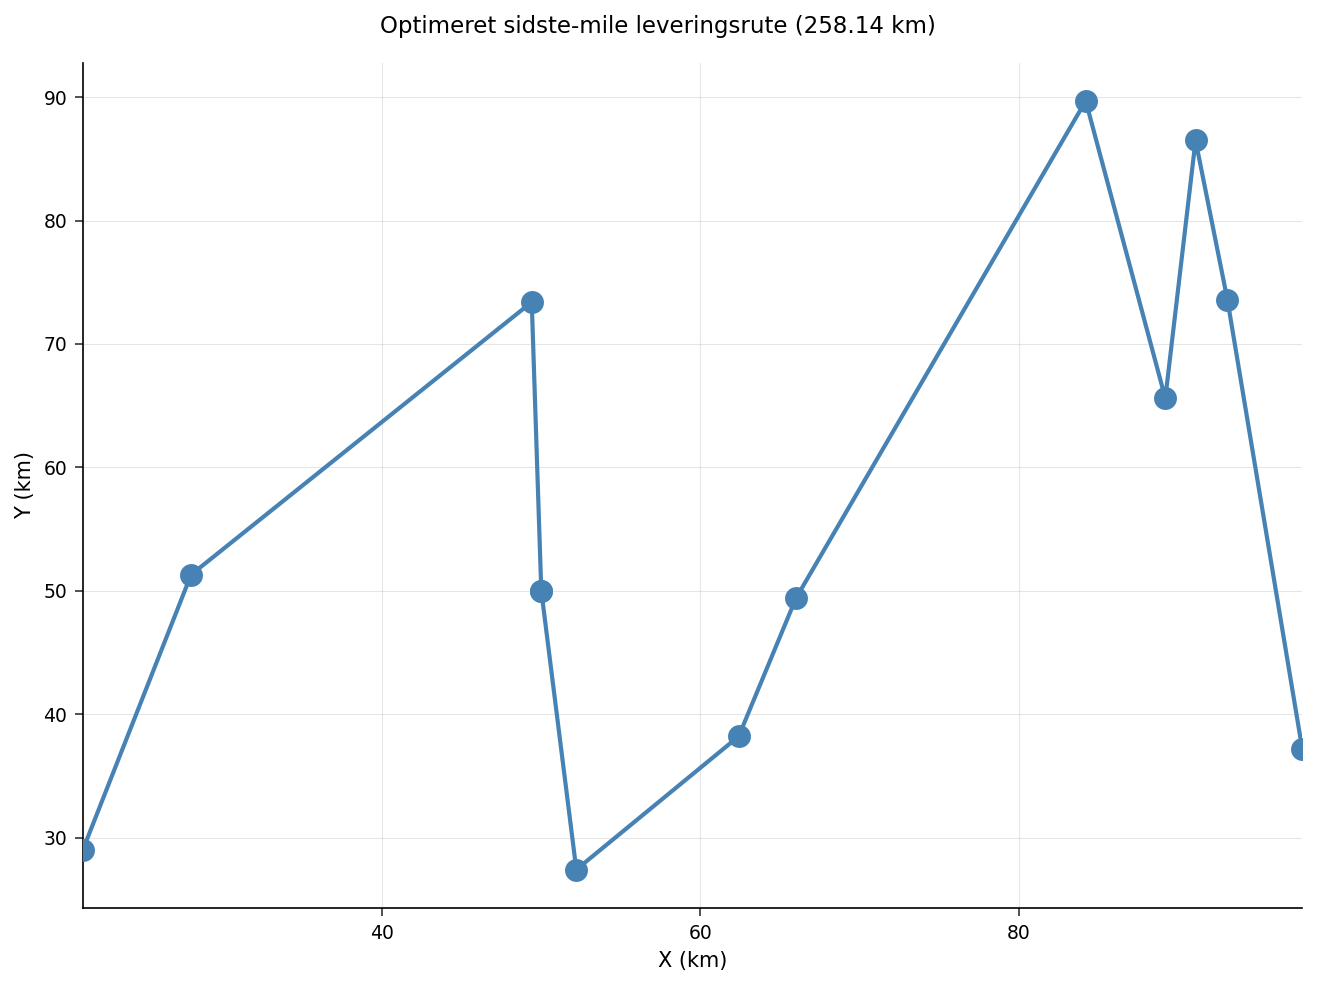

In [5]:
PROCEDURE SGPLOT data=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS MÆRKAT='X (km)' grid;
    YAXIS MÆRKAT='Y (km)' grid;
    TITEL "Optimeret sidste-mile leveringsrute (&total_km km)";
KØR;

## Fortolkning af resultaterne

- **Ruten.** Tabellerne `route` og `manifest` viser den lukkede tur, som
  OPTMODEL-netværkets TSP-løser producerede over den fulde graf af 12 stop, med
  start og slut ved depotet. `Total Distance` er *målt*: det er summen af de
  euklidiske afstande pr. etape (`leg_km`), så den afspejler den reelle geometri
  i netværket frem for et påstået tal.
- **Hvorfor en netværksløser her.** Med 11 kundestop findes der
  `11! / 2 = 19.958.400` forskellige lukkede ture, så dispatcheren har brug for
  en algoritme frem for en optælling. `SOLVE WITH NETWORK / TSP` konstruerer en
  tur direkte ud fra det vægtede kantsæt, uden at analytikeren manuelt koder
  søgningen.
- **Fra rækkefølge til manifest.** Løseren returnerer en besøgs*rækkefølge*;
  DATA-trinnet omdanner det til et operationelt artefakt — navngivne stop,
  afstande pr. etape, en løbende kilometertæller og et enkeltlinjemanifest, en
  chauffør kan følge.
- **Operationelle udvidelser.** Den samme OPTMODEL-skabelon skalerer til rigere
  ruteplanlægning: tilføj kapacitets- eller tidsvinduesbegrænsninger som
  yderligere netværksmuligheder, vægt kanter efter køretid i stedet for
  ligeud-afstand, eller opdel stop på flere køretøjer, før der løses en TSP pr.
  køretøj.